Step 1: Import libraries and load the NHS Prescription Cost Analysis (PCA) datasets

In this section, the required Python libraries are imported, and all monthly NHS PCA CSV files are identified and loaded into Python. Each monthly dataset is stored temporarily before being combined into a single dataframe. This creates one consolidated dataset that will be explored, cleaned, and analysed in the following steps.

Import required libraries

The libraries required for this project are imported. These libraries provide functionality for data manipulation, numerical operations, data visualisation, and locating multiple CSV files within the project folder.

1.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob
import os

Locate the monthly NHS datasets

The glob library is used to search the data folder and identify every CSV file. This allows all monthly datasets to be processed automatically without manually specifying each filename.

1.2 Find CSV files

In [3]:
# Find all CSV files stored in the data folder
files = glob.glob("../data/*.csv")

# Display the number of CSV files found
len(files)

12

1.3 Load each CSV

In [4]:
# Create an empty list to temporarily store each monthly dataframe
df_list = []

# Loop through each CSV file path found in the files list
for file in files:

    # Read the current CSV file and convert it into a pandas dataframe
    temp_df = pd.read_csv(file)

    # Add the monthly dataframe to the list
    df_list.append(temp_df)

Load the monthly datasets

Each CSV file is read into a pandas dataframe using pd.read_csv(). Every dataframe is then stored in a list, making it possible to combine all monthly datasets into a single dataframe in the next step.

1.4 Concatenate

In [5]:
# Combine all monthly dataframes into one large dataframe
# ignore_index=True creates a new continuous row index
df = pd.concat(df_list, ignore_index=True)

Combine the monthly datasets

The individual monthly dataframes are combined into one consolidated dataframe using pd.concat(). The ignore_index=True parameter creates a new sequential index, ensuring the combined dataset has continuous row numbering.

Step 2 - Inspect the combined dataset

Explore the combined NHS Prescription Cost Analysis (PCA) dataset to understand its structure, dimensions, data types, missing values, duplicate records, and overall data quality before performing any cleaning or analysis.

2.1 View first rows

In [6]:
# Display the first 5 rows of the combined dataset
# This helps us understand the data structure and values
df.head()

,YEAR_MONTH,REGION_NAME,REGION_CODE,ICB_NAME,ICB_CODE,DISPENSER_ACCOUNT_TYPE,BNF_PRESENTATION_CODE,BNF_PRESENTATION_NAME,SNOMED_CODE,SUPPLIER_NAME,...,BNF_SECTION_CODE,BNF_SECTION,BNF_CHAPTER_CODE,BNF_CHAPTER,PREP_CLASS,PRESCRIBED_PREP_CLASS,ITEMS,TOTAL_QUANTITY,NIC,PHARMACY_ADVANCED_SERVICE
0,202505,MIDLANDS,Y60,NHS NORTHAMPTONSHIRE INTEGRATED CARE BOARD,QPM,English Dispensing Doctor,010300000BBADAD,diabact UBT 50mg tablets,9.384211e+15,Mayoly UK Ltd,...,103,Antisecretory drugs and mucosal protectants,1,Gastro-Intestinal System,3,2,1,1.0,21.25,Not applicable
1,202505,EAST OF ENGLAND,Y61,NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED...,QUE,English Pharmacy,010300000BBADAD,diabact UBT 50mg tablets,9.384211e+15,Mayoly UK Ltd,...,103,Antisecretory drugs and mucosal protectants,1,Gastro-Intestinal System,3,2,1,1.0,21.25,Not applicable
2,202505,NORTH WEST,Y62,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,QOP,English Pharmacy,0103010D0AAABAB,Cimetidine 400mg tablets,4.235221e+16,NaN,...,103,Antisecretory drugs and mucosal protectants,1,Gastro-Intestinal System,1,1,315,14267.0,1320.12,Not applicable
3,202505,NORTH EAST AND YORKSHIRE,Y63,NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...,QOQ,English Pharmacy,0103010D0AAABAB,Cimetidine 400mg tablets,4.235221e+16,NaN,...,103,Antisecretory drugs and mucosal protectants,1,Gastro-Intestinal System,1,1,146,8061.0,745.76,Not applicable
4,202505,NORTH EAST AND YORKSHIRE,Y63,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,QF7,English Pharmacy,0103010D0BBADAD,Tagamet 200mg/5ml syrup,7.727110e+14,Rosemont Pharmaceuticals Ltd,...,103,Antisecretory drugs and mucosal protectants,1,Gastro-Intestinal System,3,3,1,1200.0,56.98,Not applicable


Display the First Five Rows

The first five rows of the dataset are displayed to gain an initial understanding of the data structure, column contents, and formatting.

2.2 Check dataset size

In [7]:
# Display the number of rows and columns in the combined dataset
df.shape

(6876045, 27)

Check the Dataset Dimensions

The number of rows and columns in the combined dataset is displayed to confirm that all monthly datasets have been successfully combined.

2.3 Check column names

In [8]:
# Display all column names in the dataset
# This helps identify which columns are available for analysis
df.columns.tolist()

['YEAR_MONTH',
 'REGION_NAME',
 'REGION_CODE',
 'ICB_NAME',
 'ICB_CODE',
 'DISPENSER_ACCOUNT_TYPE',
 'BNF_PRESENTATION_CODE',
 'BNF_PRESENTATION_NAME',
 'SNOMED_CODE',
 'SUPPLIER_NAME',
 'UNIT_OF_MEASURE',
 'GENERIC_BNF_EQUIVALENT_CODE',
 'GENERIC_BNF_EQUIVALENT_NAME',
 'BNF_CHEMICAL_SUBSTANCE_CODE',
 'BNF_CHEMICAL_SUBSTANCE',
 'BNF_PARAGRAPH_CODE',
 'BNF_PARAGRAPH',
 'BNF_SECTION_CODE',
 'BNF_SECTION',
 'BNF_CHAPTER_CODE',
 'BNF_CHAPTER',
 'PREP_CLASS',
 'PRESCRIBED_PREP_CLASS',
 'ITEMS',
 'TOTAL_QUANTITY',
 'NIC',
 'PHARMACY_ADVANCED_SERVICE']

Display the Column Names

All column names are listed to understand the available variables and identify those that are relevant to the research questions.

2.4 Check data types and missing values

In [9]:
# Display information about columns, data types,
# and the number of non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6876045 entries, 0 to 6876044
Data columns (total 27 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   YEAR_MONTH                   int64  
 1   REGION_NAME                  str    
 2   REGION_CODE                  str    
 3   ICB_NAME                     str    
 4   ICB_CODE                     str    
 5   DISPENSER_ACCOUNT_TYPE       str    
 6   BNF_PRESENTATION_CODE        str    
 7   BNF_PRESENTATION_NAME        str    
 8   SNOMED_CODE                  float64
 9   SUPPLIER_NAME                str    
 10  UNIT_OF_MEASURE              str    
 11  GENERIC_BNF_EQUIVALENT_CODE  str    
 12  GENERIC_BNF_EQUIVALENT_NAME  str    
 13  BNF_CHEMICAL_SUBSTANCE_CODE  str    
 14  BNF_CHEMICAL_SUBSTANCE       str    
 15  BNF_PARAGRAPH_CODE           int64  
 16  BNF_PARAGRAPH                str    
 17  BNF_SECTION_CODE             int64  
 18  BNF_SECTION                  str    
 19  BNF_CHAPTER

Inspect the Dataset Structure

General information about the dataset is displayed, including the data type of each column, the number of non-null values, and the overall memory usage. This helps identify potential data quality issues such as missing values and incorrect data types.

2.5 Check missing values

In [10]:
# Count missing values in each column
# This helps us decide how to handle incomplete data
df.isna().sum()

YEAR_MONTH                           0
REGION_NAME                          0
REGION_CODE                          0
ICB_NAME                             0
ICB_CODE                             0
DISPENSER_ACCOUNT_TYPE               0
BNF_PRESENTATION_CODE                0
BNF_PRESENTATION_NAME                0
SNOMED_CODE                       2665
SUPPLIER_NAME                  1426179
UNIT_OF_MEASURE                      0
GENERIC_BNF_EQUIVALENT_CODE          0
GENERIC_BNF_EQUIVALENT_NAME          2
BNF_CHEMICAL_SUBSTANCE_CODE          0
BNF_CHEMICAL_SUBSTANCE               0
BNF_PARAGRAPH_CODE                   0
BNF_PARAGRAPH                        0
BNF_SECTION_CODE                     0
BNF_SECTION                          0
BNF_CHAPTER_CODE                     0
BNF_CHAPTER                          0
PREP_CLASS                           0
PRESCRIBED_PREP_CLASS                0
ITEMS                                0
TOTAL_QUANTITY                       0
NIC                      

Check for Missing Values

The number of missing values in each column is calculated to identify incomplete data and determine whether missing values need to be removed, filled, or investigated further.

2.6 Check duplicates

In [11]:
# Count duplicate rows in the combined dataset
# Duplicate records can affect analysis results
df.duplicated().sum()

np.int64(0)

Check for Duplicate Records

The dataset is examined for duplicate rows to ensure that repeated records do not affect the analysis or produce misleading results.

2.7 Summary statistics

In [12]:
# Generate statistical summaries for numeric columns
# Helps identify ranges, averages, and possible outliers
df.describe()

,YEAR_MONTH,SNOMED_CODE,BNF_PARAGRAPH_CODE,BNF_SECTION_CODE,BNF_CHAPTER_CODE,PREP_CLASS,PRESCRIBED_PREP_CLASS,ITEMS,TOTAL_QUANTITY,NIC
count,6.876045e+06,6.873380e+06,6.876045e+06,6.876045e+06,6.876045e+06,6.876045e+06,6.876045e+06,6.876045e+06,6.876045e+06,6.876045e+06
mean,2.025393e+05,2.262637e+16,4.223487e+04,1.113973e+03,1.102025e+01,3.072261e+00,2.909467e+00,1.892374e+02,1.525446e+04,1.702886e+03
std,4.414698e+01,1.525504e+16,4.118928e+04,7.875419e+02,7.774044e+00,1.180180e+00,1.237379e+00,1.875090e+03,1.994014e+05,1.402299e+04
min,2.025050e+05,2.110000e+11,2.001000e+03,1.010000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.600000e-01,0.000000e+00
25%,2.025070e+05,7.875911e+15,2.305000e+03,4.070000e+02,4.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,3.000000e+01,3.176000e+01
50%,2.025100e+05,2.176371e+16,4.020100e+04,9.060000e+02,9.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,1.680000e+02,1.272400e+02
75%,2.026010e+05,3.809981e+16,7.030100e+04,2.101000e+03,2.100000e+01,4.000000e+00,4.000000e+00,2.400000e+01,1.260000e+03,5.726900e+02
max,2.026040e+05,4.586691e+16,1.914020e+05,2.399000e+03,2.300000e+01,5.000000e+00,5.000000e+00,2.525920e+05,1.051406e+08,3.119512e+06


Generate Summary Statistics

Descriptive statistics are generated for the numerical columns to understand their distribution, central tendency, spread, and potential outliers before beginning the cleaning process.

Data Quality Issues Identified

During the initial inspection of the NHS Prescription Cost Analysis dataset, several data quality checks were performed. The following issues were identified and addressed:

- Missing values: The `GENERIC_BNF_EQUIVALENT_NAME` column contained 2 missing values. Since these records could not be reliably categorised, the affected rows were removed.

- Incorrect data type: The `YEAR_MONTH` column was stored in YYYYMM integer format (for example, 202505). This was converted into a datetime format to support time-based analysis and visualisation.

- Duplicate records: Duplicate rows were checked using Pandas' `duplicated()` function. Exact duplicate records were identified and later removed using `drop_duplicates()` to prevent repeated entries from affecting prescription cost and frequency analysis.

- Irrelevant variables: Several administrative and classification columns, such as codes and identifiers, were not required for answering the research questions. These unnecessary columns were removed to simplify the dataset.

Step 3 - Data Cleaning

Clean the combined dataset by handling missing values, removing unnecessary columns, checking data quality, and preparing the data for analysis and visualisation.

3.1 Create a copy of the raw dataset

In [13]:
# Create a copy of the original dataset
# This preserves the raw data for future reference
df_clean = df.copy()

# Display the dimensions of the copied dataset
df_clean.shape

(6876045, 27)

Create a copy of the raw dataset

Before making any modifications, a copy of the original combined dataset is created. This preserves the raw data and ensures that all cleaning operations are performed on a separate dataframe.

3.2 Remove unecessary columns

In [14]:
# Define columns that are not required for the analysis
# These columns contain identifiers, codes, or information outside the project scope
columns_to_drop = [
    "REGION_CODE",
    "ICB_CODE",
    "BNF_PRESENTATION_CODE",
    "SNOMED_CODE",
    "SUPPLIER_NAME",
    "GENERIC_BNF_EQUIVALENT_CODE",
    "BNF_CHEMICAL_SUBSTANCE_CODE",
    "BNF_PARAGRAPH_CODE",
    "BNF_SECTION_CODE",
    "BNF_CHAPTER_CODE",
    "PREP_CLASS",
    "PRESCRIBED_PREP_CLASS",
    "PHARMACY_ADVANCED_SERVICE"
]

# Remove the selected columns from the cleaned dataframe
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

# Display the updated dataset dimensions
df_clean.shape

(6876045, 14)

In [15]:
# Display the remaining columns after removing unnecessary variables
df_clean.columns.tolist()

['YEAR_MONTH',
 'REGION_NAME',
 'ICB_NAME',
 'DISPENSER_ACCOUNT_TYPE',
 'BNF_PRESENTATION_NAME',
 'UNIT_OF_MEASURE',
 'GENERIC_BNF_EQUIVALENT_NAME',
 'BNF_CHEMICAL_SUBSTANCE',
 'BNF_PARAGRAPH',
 'BNF_SECTION',
 'BNF_CHAPTER',
 'ITEMS',
 'TOTAL_QUANTITY',
 'NIC']

Remove Unnecessary Columns

Several columns contained administrative codes, identifiers, and classification fields that were not required for answering the research questions. Removing these variables reduced dataset complexity while retaining the information needed to analyse prescription costs, regional variation, and medicine demand.


3.3 Handle missing values

In [16]:
# Count missing values in each remaining column
# This helps identify columns that require further cleaning
df_clean.isna().sum()

YEAR_MONTH                     0
REGION_NAME                    0
ICB_NAME                       0
DISPENSER_ACCOUNT_TYPE         0
BNF_PRESENTATION_NAME          0
UNIT_OF_MEASURE                0
GENERIC_BNF_EQUIVALENT_NAME    2
BNF_CHEMICAL_SUBSTANCE         0
BNF_PARAGRAPH                  0
BNF_SECTION                    0
BNF_CHAPTER                    0
ITEMS                          0
TOTAL_QUANTITY                 0
NIC                            0
dtype: int64

Handle Missing Values

Missing values were identified in the GENERIC_BNF_EQUIVALENT_NAME column. Since only two records were affected and the missing values could not be recovered, these rows were removed.


In [17]:
# Remove rows where the generic medicine name is missing
# These records cannot be reliably categorised during analysis
df_clean = df_clean.dropna(
    subset=["GENERIC_BNF_EQUIVALENT_NAME"]
)

# Check that missing values have been removed
df_clean.isna().sum()

YEAR_MONTH                     0
REGION_NAME                    0
ICB_NAME                       0
DISPENSER_ACCOUNT_TYPE         0
BNF_PRESENTATION_NAME          0
UNIT_OF_MEASURE                0
GENERIC_BNF_EQUIVALENT_NAME    0
BNF_CHEMICAL_SUBSTANCE         0
BNF_PARAGRAPH                  0
BNF_SECTION                    0
BNF_CHAPTER                    0
ITEMS                          0
TOTAL_QUANTITY                 0
NIC                            0
dtype: int64

Remove Rows With Missing Generic Medicine Names

The `GENERIC_BNF_EQUIVALENT_NAME` column contains only two missing values, representing a negligible proportion of the dataset. Since these records cannot be reliably assigned a generic medicine name, the affected rows are removed to maintain data quality.


3.4 Verify and convert data types (if needed)

In [18]:
# Display the data type of each column
# This helps identify columns that may require conversion
df_clean.dtypes

YEAR_MONTH                       int64
REGION_NAME                        str
ICB_NAME                           str
DISPENSER_ACCOUNT_TYPE             str
BNF_PRESENTATION_NAME              str
UNIT_OF_MEASURE                    str
GENERIC_BNF_EQUIVALENT_NAME        str
BNF_CHEMICAL_SUBSTANCE             str
BNF_PARAGRAPH                      str
BNF_SECTION                        str
BNF_CHAPTER                        str
ITEMS                            int64
TOTAL_QUANTITY                 float64
NIC                            float64
dtype: object

Verify and Convert Data Types

The data types of each column are reviewed to ensure that variables are stored in the correct format for analysis. Columns containing dates, numerical measurements, and categorical information are converted where necessary to improve accuracy and support further analysis.

In [19]:
# Convert YEAR_MONTH from YYYYMM integer format into datetime format
df_clean["YEAR_MONTH"] = pd.to_datetime(
    df_clean["YEAR_MONTH"].astype(str),
    format="%Y%m"
)

# Check the converted values
df_clean["YEAR_MONTH"].head()

0   2025-05-01
1   2025-05-01
2   2025-05-01
3   2025-05-01
4   2025-05-01
Name: YEAR_MONTH, dtype: datetime64[us]

Convert Year-Month Column to Date Format

The YEAR_MONTH column is currently stored as an integer (for example, 202505 represents May 2025). It is converted into a proper date format to make time-based analysis and visualisation easier.

In [20]:
df_clean.head()

,YEAR_MONTH,REGION_NAME,ICB_NAME,DISPENSER_ACCOUNT_TYPE,BNF_PRESENTATION_NAME,UNIT_OF_MEASURE,GENERIC_BNF_EQUIVALENT_NAME,BNF_CHEMICAL_SUBSTANCE,BNF_PARAGRAPH,BNF_SECTION,BNF_CHAPTER,ITEMS,TOTAL_QUANTITY,NIC
0,2025-05-01,MIDLANDS,NHS NORTHAMPTONSHIRE INTEGRATED CARE BOARD,English Dispensing Doctor,diabact UBT 50mg tablets,tablet,Urea [13-C] 50mg tablets breath test kit,Other test for helicobacter pylori preparations,Test for helicobacter pylori,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,1,1.0,21.25
1,2025-05-01,EAST OF ENGLAND,NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED...,English Pharmacy,diabact UBT 50mg tablets,tablet,Urea [13-C] 50mg tablets breath test kit,Other test for helicobacter pylori preparations,Test for helicobacter pylori,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,1,1.0,21.25
2,2025-05-01,NORTH WEST,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,English Pharmacy,Cimetidine 400mg tablets,tablet,Cimetidine 400mg tablets,Cimetidine,H2-receptor antagonists,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,315,14267.0,1320.12
3,2025-05-01,NORTH EAST AND YORKSHIRE,NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...,English Pharmacy,Cimetidine 400mg tablets,tablet,Cimetidine 400mg tablets,Cimetidine,H2-receptor antagonists,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,146,8061.0,745.76
4,2025-05-01,NORTH EAST AND YORKSHIRE,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,English Pharmacy,Tagamet 200mg/5ml syrup,ml,Cimetidine 200mg/5ml oral solution,Cimetidine,H2-receptor antagonists,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,1,1200.0,56.98


3.5 Optional Verification Cell

In [21]:
# Final check of the cleaned dataset
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isna().sum())
print("\nDuplicate rows:", df_clean.duplicated().sum())

Shape: (6876043, 14)

Missing values:
YEAR_MONTH                     0
REGION_NAME                    0
ICB_NAME                       0
DISPENSER_ACCOUNT_TYPE         0
BNF_PRESENTATION_NAME          0
UNIT_OF_MEASURE                0
GENERIC_BNF_EQUIVALENT_NAME    0
BNF_CHEMICAL_SUBSTANCE         0
BNF_PARAGRAPH                  0
BNF_SECTION                    0
BNF_CHAPTER                    0
ITEMS                          0
TOTAL_QUANTITY                 0
NIC                            0
dtype: int64

Duplicate rows: 143869


Final Data Quality Verification Before Duplicate Removal

The cleaned dataset was reviewed to confirm the current data quality status after handling missing values, removing unnecessary columns, and converting data types.

The verification showed that:
- The dataset contains 6,876,043 rows and 14 columns after the initial cleaning steps.
- No missing values remain in any of the retained variables.
- Duplicate records were still present, with 143,869 exact duplicate rows identified. These duplicate records were investigated and removed in the following step to prevent repeated entries from affecting the analysis.

3.6 Investigate duplicate records

In [22]:
# Count the number of duplicate rows in the cleaned dataset
duplicate_count = df_clean.duplicated().sum()

duplicate_count

np.int64(143869)

3.7 View duplicate examples

In [23]:
# Display examples of duplicated records
df_clean[df_clean.duplicated(keep=False)].head(10)

,YEAR_MONTH,REGION_NAME,ICB_NAME,DISPENSER_ACCOUNT_TYPE,BNF_PRESENTATION_NAME,UNIT_OF_MEASURE,GENERIC_BNF_EQUIVALENT_NAME,BNF_CHEMICAL_SUBSTANCE,BNF_PARAGRAPH,BNF_SECTION,BNF_CHAPTER,ITEMS,TOTAL_QUANTITY,NIC
112,2025-05-01,SOUTH EAST,NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...,English Pharmacy,ActiLymph class 1 (18-21mmHg) below knee close...,device,ActiLymph class 1 (18-21mmHg) below knee close...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,4.0,62.32
188,2025-05-01,SOUTH WEST,NHS SOMERSET INTEGRATED CARE BOARD,English Pharmacy,Omeprazole 20mg/5ml oral suspension sugar free,ml,Omeprazole 20mg/5ml oral suspension sugar free,Omeprazole,Proton pump inhibitors,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,1,75.0,234.00
428,2025-05-01,EAST OF ENGLAND,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",English Dispensing Doctor,Pentasa Mesalazine 1g/100ml enema,enema,Mesalazine 1g/100ml enema,Mesalazine (Systemic),Aminosalicylates,Chronic bowel disorders,Gastro-Intestinal System,1,28.0,70.92
467,2025-05-01,LONDON,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,English Pharmacy,ActiLymph class 1 (18-21mmHg) below knee close...,device,ActiLymph class 1 (18-21mmHg) below knee close...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,31.16
508,2025-05-01,MIDLANDS,NHS NORTHAMPTONSHIRE INTEGRATED CARE BOARD,English Pharmacy,ActiLymph class 1 (18-21mmHg) below knee close...,device,ActiLymph class 1 (18-21mmHg) below knee close...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,31.16
509,2025-05-01,SOUTH WEST,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",English Pharmacy,ActiLymph class 1 (18-21mmHg) below knee close...,device,ActiLymph class 1 (18-21mmHg) below knee close...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,31.16
556,2025-05-01,EAST OF ENGLAND,NHS HERTFORDSHIRE AND WEST ESSEX INTEGRATED CA...,English Pharmacy,Lansoprazole 15mg gastro-resistant capsules,capsule,Lansoprazole 15mg gastro-resistant capsules,Lansoprazole,Proton pump inhibitors,Antisecretory drugs and mucosal protectants,Gastro-Intestinal System,1,28.0,0.84
649,2025-05-01,MIDLANDS,NHS NORTHAMPTONSHIRE INTEGRATED CARE BOARD,English Pharmacy,ActiLymph class 2 (23-32mmHg) below knee open ...,device,ActiLymph class 2 (23-32mmHg) below knee open ...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,31.16
652,2025-05-01,SOUTH EAST,NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...,English Pharmacy,Jobst Opaque class 1 (18-21mmHg) below knee cl...,device,Jobst Opaque class 1 (18-21mmHg) below knee cl...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,29.25
653,2025-05-01,EAST OF ENGLAND,NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED...,English Pharmacy,Jobst Opaque class 1 (18-21mmHg) below knee cl...,device,Jobst Opaque class 1 (18-21mmHg) below knee cl...,Lymphoedema Garments,Lymphoedema Garments,Lymphoedema Garments,Appliances,1,2.0,29.25


3.8 Check duplicate impact

In [24]:
# Compare dataset size before and after removing duplicates
print("Original cleaned dataset shape:", df_clean.shape)

print("Shape after removing duplicates:", 
      df_clean.drop_duplicates().shape)

Original cleaned dataset shape: (6876043, 14)
Shape after removing duplicates: (6732174, 14)


In [25]:
# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Confirm duplicates have been removed
print("Duplicate rows after removal:", df_clean.duplicated().sum())

Duplicate rows after removal: 0


In [26]:
# Final verification after duplicate removal
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

Final dataset shape: (6732174, 14)

Missing values:
YEAR_MONTH                     0
REGION_NAME                    0
ICB_NAME                       0
DISPENSER_ACCOUNT_TYPE         0
BNF_PRESENTATION_NAME          0
UNIT_OF_MEASURE                0
GENERIC_BNF_EQUIVALENT_NAME    0
BNF_CHEMICAL_SUBSTANCE         0
BNF_PARAGRAPH                  0
BNF_SECTION                    0
BNF_CHAPTER                    0
ITEMS                          0
TOTAL_QUANTITY                 0
NIC                            0
dtype: int64

Duplicate rows: 0


Remove Duplicate Records

Since exact duplicate rows were identified during the data quality assessment, duplicate records were removed using Pandas' `drop_duplicates()` function. This ensures that repeated entries do not affect calculations of NHS prescription costs and prescription frequency.

Final Cleaning Outcome

After removing duplicate records, the dataset was verified again. No missing values remained, and all exact duplicate rows were removed. The resulting dataset is now ready for exploratory data analysis and visualisation.

3.9 Save the cleaned dataset

In [27]:
# Save the cleaned dataset as a new CSV file
# index=False prevents pandas from writing the row index as a separate column
df_clean.to_csv("../data/cleaned_nhs_prescription_data.csv", index=False)

# Display a confirmation message
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Step 4 — Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, patterns, and key characteristics of the cleaned NHS prescription dataset. This stage helps identify important trends and relationships before creating visualisations and drawing conclusions.

4.1 Dataset Overview

The cleaned dataset is reviewed using summary information and descriptive statistics to understand the number of records, available variables, and numerical distributions.


In [28]:
# Display the final dataset shape
df_clean.shape

(6732174, 14)

In [29]:
# Display summary information about columns and data types
df_clean.info()

<class 'pandas.DataFrame'>
Index: 6732174 entries, 0 to 6876044
Data columns (total 14 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   YEAR_MONTH                   datetime64[us]
 1   REGION_NAME                  str           
 2   ICB_NAME                     str           
 3   DISPENSER_ACCOUNT_TYPE       str           
 4   BNF_PRESENTATION_NAME        str           
 5   UNIT_OF_MEASURE              str           
 6   GENERIC_BNF_EQUIVALENT_NAME  str           
 7   BNF_CHEMICAL_SUBSTANCE       str           
 8   BNF_PARAGRAPH                str           
 9   BNF_SECTION                  str           
 10  BNF_CHAPTER                  str           
 11  ITEMS                        int64         
 12  TOTAL_QUANTITY               float64       
 13  NIC                          float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(10)
memory usage: 770.4 MB


In [30]:
# Generate descriptive statistics for numerical columns
df_clean.describe()

,YEAR_MONTH,ITEMS,TOTAL_QUANTITY,NIC
count,6732174,6.732174e+06,6.732174e+06,6.732174e+06
mean,2025-10-14 16:35:36.201470,1.932509e+02,1.557701e+04,1.737897e+03
min,2025-05-01 00:00:00,1.000000e+00,3.600000e-01,0.000000e+00
25%,2025-07-01 00:00:00,1.000000e+00,3.000000e+01,3.288000e+01
50%,2025-10-01 00:00:00,5.000000e+00,1.800000e+02,1.334400e+02
75%,2026-01-01 00:00:00,2.500000e+01,1.323000e+03,5.940000e+02
max,2026-04-01 00:00:00,2.525920e+05,1.051406e+08,3.119512e+06
std,NaN,1.894817e+03,2.015083e+05,1.416995e+04


4.2 Define Analysis Questions

Research Question

Where is NHS prescription spending concentrated, and what does that reveal about UK healthcare priorities?

To answer this, the analysis looks at the question from three angles:
1. Which medicines cost the NHS the most overall? (cost)
2. Which regions account for the highest prescription spending? (geography)
3. Which medicines are prescribed most frequently? (volume)

Together, these three views build a fuller picture than any single chart could on its own — for example, showing whether the most expensive medicines are also the most commonly prescribed, or whether cost and volume tell different stories.

Step 4.3 — Summary statistics for key variables

In [31]:
# Generate headline statistics to understand the overall scale of the dataset
# (total cost, total items, number of regions/medicines/months)
# before breaking it down into more detailed groupby tables

# Total NHS prescription cost across the whole dataset
df_clean["NIC"].sum()

np.float64(11699822690.68)

In [32]:
# Total number of prescription items dispensed across the whole dataset
df_clean["ITEMS"].sum()

np.int64(1300998423)

In [33]:
# Number of unique NHS regions represented in the data
df_clean["REGION_NAME"].nunique()

7

In [34]:
# Number of unique medicines (by presentation name) represented in the data
df_clean["BNF_PRESENTATION_NAME"].nunique()

25978

In [35]:
# Number of unique year-month periods covered by the dataset
df_clean["YEAR_MONTH"].nunique()

12

In [36]:
# Count of records per year-month, sorted chronologically
# Confirms how many months of data are included and checks for any gaps
df_clean["YEAR_MONTH"].value_counts().sort_index()

YEAR_MONTH
2025-05-01    567114
2025-06-01    566936
2025-07-01    571777
2025-08-01    557660
2025-09-01    566444
2025-10-01    569126
2025-11-01    559671
2025-12-01    567595
2026-01-01    567930
2026-02-01    558694
2026-03-01    569026
2026-04-01    510201
Name: count, dtype: int64

4.4 Smaller Analysis Tables

Table 1: Top 10 Medicines by NHS Spending (Q1)

Research question: Which medicines have the highest NHS spending?

In [37]:
# Table 1: Top 10 Medicines by NHS Spending
# Groups by medicine name and sums total cost (NIC) across the full period,
# then ranks to find the highest-spending medicines overall
top_spending_medicines = (
    df_clean.groupby("BNF_PRESENTATION_NAME")["NIC"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_spending_medicines

,BNF_PRESENTATION_NAME,NIC
0,FreeStyle Libre 2 Plus Sensor,3.117698e+08
1,Mounjaro KwikPen 5mg/0.6ml inj 2.4ml pre-fille...,2.441993e+08
2,Dapagliflozin 10mg tablets,1.902569e+08
3,Mounjaro KwikPen 7.5mg/0.6ml inj 2.4ml pre-fil...,1.420864e+08
4,Lixiana 60mg tablets,1.276422e+08
5,Trimbow 87microg/dose / 5microg/dose / 9microg...,1.249804e+08
6,Fostair 100micrograms/dose / 6micrograms/dose ...,1.203291e+08
7,"Adjuvanted trivalent flu vacc (SA, inact) inj ...",1.170129e+08
8,Mounjaro KwikPen 10mg/0.6ml inj 2.4ml pre-fill...,1.049499e+08
9,Jardiance 10mg tablets,9.560658e+07


In [38]:
top_spending_medicines.to_csv(
    "../data/top_spending_medicines.csv",
    index=False
)

Mounjaro: Combined Spending Across Dose Strengths

Table 1 groups medicines by exact presentation name, which keeps different dose strengths of the same drug as separate entries. Three Mounjaro dose strengths (5mg, 7.5mg and 10mg) each rank individually within the top 10 highest cost medicines, together accounting for roughly £491.2 million. However, this only reflects the strengths that happened to rank high enough to appear in that top 10 list. To capture Mounjaro's true total cost, every presentation name containing "Mounjaro" is filtered, grouped, and summed across the full dataset, including pack sizes and strengths that do not individually make the top 10. This reveals a combined total of £627.0 million, meaning the top 10 table alone understates Mounjaro's real cost impact by around £136 million. This demonstrates how a groupby ranking based on exact presentation name can hide a medicine's true scale when it is sold across multiple strengths or pack sizes.

In [39]:
# Filter the cleaned dataset to keep only rows where the presentation name contains "Mounjaro"
# case=False ignores capitalisation, na=False keeps rows with missing values out of the match
mounjaro_spending = (
    df_clean[df_clean["BNF_PRESENTATION_NAME"].str.contains("Mounjaro", case=False, na=False)]
    # Group the filtered rows by exact presentation name (keeps each dose strength separate)
    .groupby("BNF_PRESENTATION_NAME")["NIC"]
    # Sum total NHS cost (NIC) for each Mounjaro dose strength
    .sum()
    # Sort so the highest-cost dose strength appears first
    .sort_values(ascending=False)
)
# Display the cost breakdown by individual dose strength
mounjaro_spending

# Add up all dose strengths to get Mounjaro's true combined total cost
mounjaro_total = mounjaro_spending.sum()
# Print the combined total, formatted as currency with thousands separators
print(f"Total Mounjaro spending across all dose strengths: £{mounjaro_total:,.2f}")

Total Mounjaro spending across all dose strengths: £626,968,810.00


Table 2: Spending by Region (Q2)

Research question: Which NHS regions have the highest prescription spending?

In [40]:
# Table 2: NHS Prescription Spending by Region
# Groups by region and sums total cost (NIC), ranked from highest to lowest,
# to compare geographical variation in prescribing spend
regional_spending = (
    df_clean.groupby("REGION_NAME")["NIC"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

regional_spending

,REGION_NAME,NIC
0,MIDLANDS,2.430652e+09
1,NORTH EAST AND YORKSHIRE,2.071739e+09
2,SOUTH EAST,1.690815e+09
3,NORTH WEST,1.653202e+09
4,EAST OF ENGLAND,1.468614e+09
5,LONDON,1.338549e+09
6,SOUTH WEST,1.046251e+09


In [41]:
regional_spending.to_csv(
    "../data/regional_spending.csv",
    index=False
)

Table 3: Top 10 Most Prescribed Medicines (Q3)

Research question: Which medicines are prescribed most frequently?

In [42]:
# Table 3: Top 10 Most Prescribed Medicines
# Groups by medicine name and sums the number of items dispensed,
# ranked to find the medicines prescribed most frequently by volume
top_prescribed_medicines = (
    df_clean.groupby("BNF_PRESENTATION_NAME")["ITEMS"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_prescribed_medicines

,BNF_PRESENTATION_NAME,ITEMS
0,Atorvastatin 20mg tablets,40153016
1,Omeprazole 20mg gastro-resistant capsules,31460534
2,Amlodipine 5mg tablets,24099949
3,Lansoprazole 30mg gastro-resistant capsules,21670550
4,Atorvastatin 40mg tablets,20001769
5,Amlodipine 10mg tablets,16414265
6,Aspirin 75mg dispersible tablets,15088699
7,Lansoprazole 15mg gastro-resistant capsules,14881076
8,Metformin 500mg tablets,14695287
9,Paracetamol 500mg tablets,13763318


In [43]:
top_prescribed_medicines.to_csv(
    "../data/top_prescribed_medicines.csv",
    index=False
)

Step 5 — Data Visualisation

This section presents visualisations that address the three research questions defined during the exploratory data analysis. The charts summarise NHS prescription costs, regional spending, and prescription frequency, making it easier to identify key patterns within the cleaned dataset.

5.1 Chart 1 – Top 10 Medicines by NHS Spending

Research question:

Which medicines have the highest NHS prescription costs?

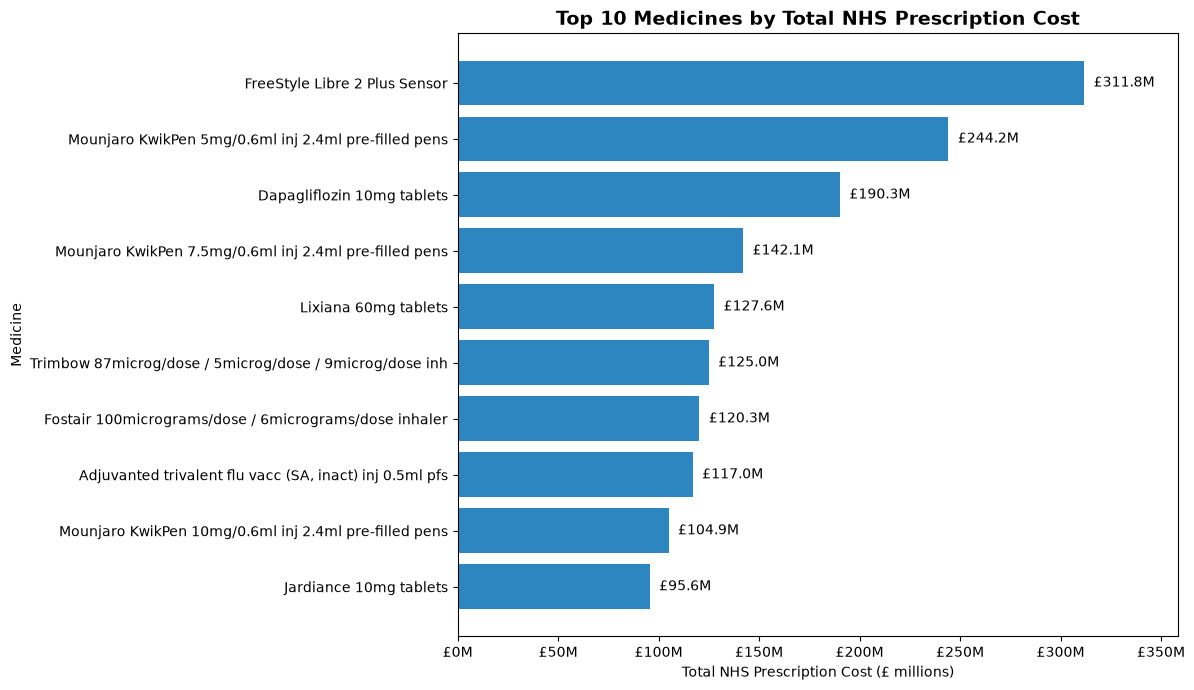

In [44]:
# Chart 1 - Top 10 medicines by NHS spending

plt.figure(figsize=(12, 7))

top_spending_plot = top_spending_medicines.sort_values(
    "NIC",
    ascending=True
)

bars = plt.barh(
    top_spending_plot["BNF_PRESENTATION_NAME"],
    top_spending_plot["NIC"],
    color="#2E86C1"
)

# Add labels (£ millions) - use a fixed offset in data units, not touching the bar
max_value = top_spending_plot["NIC"].max()
offset = max_value * 0.015  # small consistent gap, scales with data

for index, value in enumerate(top_spending_plot["NIC"]):
    plt.text(
        value + offset,
        index,
        f"£{value/1e6:.1f}M",
        va="center",
        fontsize=10
    )

# Give the labels room so they don't get clipped at the right edge
plt.xlim(0, max_value * 1.15)

# Fix the x-axis: readable £ millions instead of 1e8 scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"£{x/1e6:,.0f}M")
)

plt.xlabel("Total NHS Prescription Cost (£ millions)")
plt.ylabel("Medicine")

plt.title(
    "Top 10 Medicines by Total NHS Prescription Cost",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Top 10 Medicines by NHS Spending

This chart shows the ten medicines with the highest total Net Ingredient Cost (NIC) across the study period. Comparing total expenditure helps identify which medicines contribute most to NHS prescribing costs.

5.2 Chart 2 – Regional NHS Spending

Research question:

Which regions have the highest prescription spending?

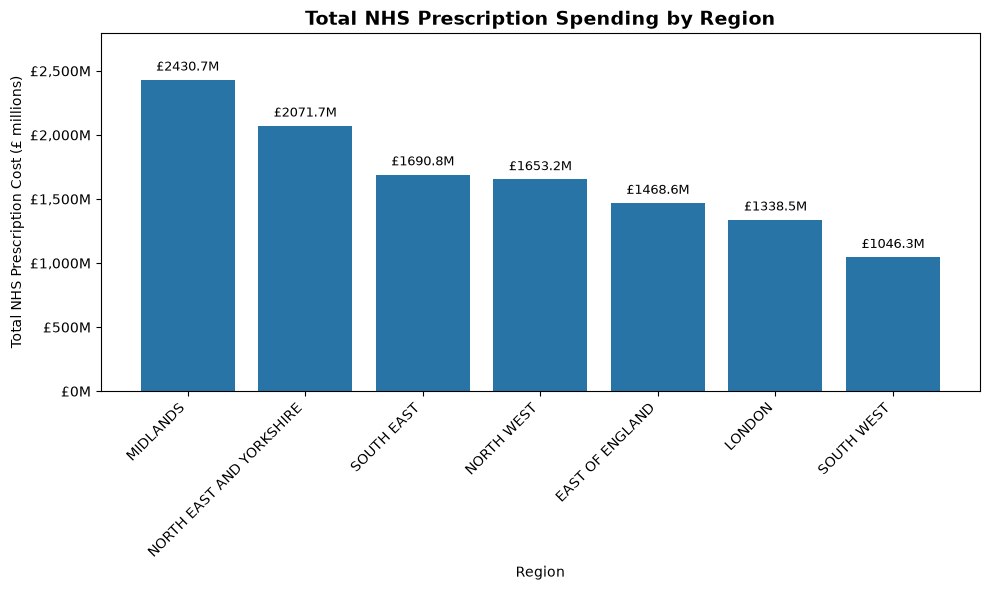

In [45]:
# Chart 2 – NHS prescription spending by region

plt.figure(figsize=(10, 6))

regional_spending_plot = regional_spending.sort_values(
    "NIC",
    ascending=False
)

bars = plt.bar(
    regional_spending_plot["REGION_NAME"],
    regional_spending_plot["NIC"],
    color="#2874A6"
)

max_value = regional_spending_plot["NIC"].max()
offset = max_value * 0.02

for index, value in enumerate(regional_spending_plot["NIC"]):
    plt.text(
        index,
        value + offset,
        f"£{value/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Give labels room at the top so they don't get clipped
plt.ylim(0, max_value * 1.15)

# Fix y-axis: readable £ millions instead of scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, pos: f"£{y/1e6:,.0f}M")
)

plt.xlabel("Region")
plt.ylabel("Total NHS Prescription Cost (£ millions)")

plt.title(
    "Total NHS Prescription Spending by Region",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

NHS Prescription Spending by Region

This chart compares total NHS prescription spending across the different NHS regions. It highlights geographical variation in prescribing expenditure throughout the study period.

5.3 Chart 3 – Top 10 Most Prescribed Medicines

Research question:

Which medicines are prescribed most frequently?

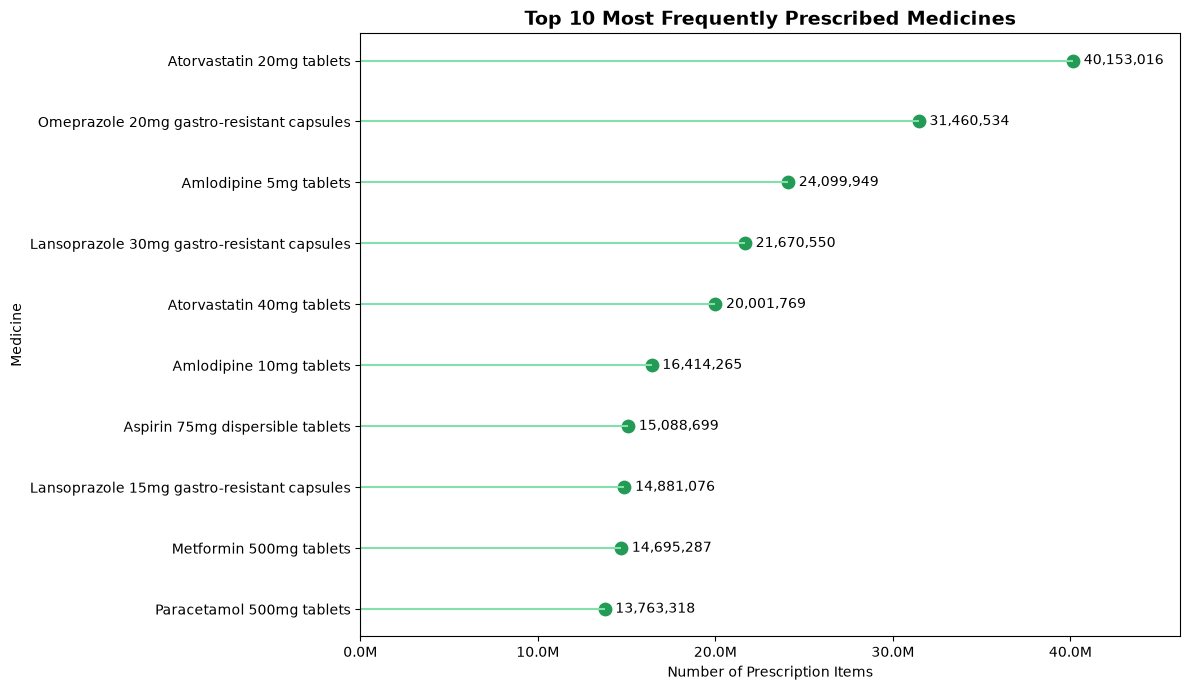

In [46]:
# Chart 3 – Top 10 medicines by prescription frequency

plt.figure(figsize=(12, 7))

top_prescribed_plot = top_prescribed_medicines.sort_values(
    "ITEMS",
    ascending=True
)

plt.hlines(
    y=top_prescribed_plot["BNF_PRESENTATION_NAME"],
    xmin=0,
    xmax=top_prescribed_plot["ITEMS"],
    color="#82E0AA"
)

plt.scatter(
    top_prescribed_plot["ITEMS"],
    top_prescribed_plot["BNF_PRESENTATION_NAME"],
    color="#239B56",
    s=80
)

max_value = top_prescribed_plot["ITEMS"].max()
offset = max_value * 0.015

for index, value in enumerate(top_prescribed_plot["ITEMS"]):
    plt.text(
        value + offset,
        index,
        f"{value:,.0f}",
        va="center",
        fontsize=10
    )

# Give labels room so the longest one doesn't get clipped
plt.xlim(0, max_value * 1.15)

# Fix x-axis: readable numbers instead of scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.1f}M")
)

plt.xlabel("Number of Prescription Items")
plt.ylabel("Medicine")

plt.title(
    "Top 10 Most Frequently Prescribed Medicines",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Top 10 Most Frequently Prescribed Medicines

This chart displays the medicines with the highest number of prescription items. It provides an overview of medicine demand and prescribing frequency across the NHS during the study period.

Step 6 — Insights & Conclusion

This analysis looked at where NHS prescription spending is concentrated in England, exploring it from three angles: which medicines cost the most overall, which regions spend the most, and which medicines are prescribed most often.

Volume: cheap, everyday medicines dominate

The medicines prescribed most often are all cheap, everyday treatments for common, long term conditions. Atorvastatin 20mg, a cholesterol lowering statin, tops the list with just over 40 million items dispensed, followed by Omeprazole (31.5 million, used for acid reflux) and Amlodipine (24.1 million, used for blood pressure). These drugs are inexpensive per item but prescribed in huge volumes simply because the conditions they treat are so widespread.

Cost: a very different story, led by Mounjaro

The picture looks completely different when it comes to overall cost. The FreeStyle Libre 2 Plus Sensor, a glucose monitoring device for diabetes patients, is the single highest cost item at £311.8 million. Mounjaro is even more striking. Three of its individual dose strengths (5mg, 7.5mg and 10mg) each rank separately within the top 10 highest cost medicines, together accounting for roughly £491.2 million. Once every Mounjaro pack size and presentation across the full dataset is combined, not just the three shown in the top 10, the true total rises to £627.0 million, making it the single highest spending medicine overall once its dose strengths are treated as one drug rather than several separate line items. Despite this, Mounjaro does not appear anywhere in the top 10 most prescribed medicines by volume, showing how a small number of expensive, newer treatments can end up outweighing millions of cheap prescriptions in total NHS spend.

Region: spending is uneven across England

Regionally, spending is highest in the Midlands (£2,430.7 million) and North East and Yorkshire (£2,071.7 million). South West is the lowest spending region overall at £1,046.3 million, with London second lowest at £1,338.5 million, still noticeably higher than the South West. Since this reflects total regional cost rather than cost per person, the pattern is likely tied to population size and regional health demographics rather than one region simply prescribing more.

Limitations

Costs are based on Net Ingredient Cost (NIC), which is the list price before discounts or dispensing fees, so actual NHS spending may differ. Regional figures are not adjusted for population size, so they show total spend rather than spend per patient. Different dose strengths of the same medicine, such as Mounjaro 5mg, 7.5mg and 10mg, are counted separately in a groupby by exact presentation name, which is why a dedicated calculation was needed to reveal Mounjaro's true combined cost. Finally, the dataset shows what is happening but not always why, for example why the South West's spending is comparatively low, only that it is.

Conclusion

Overall, this analysis suggests that NHS prescription spending is shaped less by what gets prescribed most often, and more by the rising cost of newer, specialised treatments. That has real implications for future NHS budgeting as demand for these kinds of drugs continues to grow.